# Basic

In [46]:
%load_ext autoreload
%autoreload all

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [47]:
import polars as pl
import pickle
import numpy as np
import tqdm
import os
import glob
import multiprocessing as mp

import src.graph_tokenizer_gd_tree_dev.config as config
import src.graph_tokenizer_gd_tree_dev.tokenizer as tokenizer
import src.graph_tokenizer_gd_tree_dev.eval as eval

In [48]:
metric_cols = ["semantic_coverage", "conciseness", "distance_score", "uniqueness_entropy",
               "unk_branche_rate", "uncovered_rate", "tree_complexity", "exact_rate", "unique_rate"]

# perf_df_all: greedy_tree_margin (6 lam values) + the baseline heuristics, straight from disk --
# robust to kernel restarts, and this is the persisted, confirmed-complete output of the
# (category, file_type, k) sweep in 4.eval_metrics.ipynb.
perf_df_base = pl.read_parquet(config.Results().perf_baseline_path).rename({"unk_rate": "unk_branche_rate"}).sort(["category", "file_type", "k"])
perf_df_greedy = pl.read_parquet(config.Results().perf_greedy_tree_path_all).rename({"unk_rate": "unk_branche_rate"}).sort(["category", "file_type", "k"])
perf_df_k_rnd = (pl.read_parquet(config.Results().perf_k_rdn_path)
                .rename({"unk_rate": "unk_branche_rate"})
                .group_by("category", "file_type", "k")
                .agg(pl.col(metric_cols).mean())
                .sort(["category", "file_type", "k"]))

# eigenvector_centrality is a degenerate baseline that always returns the same candidate set
# for all k, so it doesn't make sense to include it in the plots.
perf_df_all = pl.concat([perf_df_base, perf_df_greedy, perf_df_k_rnd], how="diagonal_relaxed").sort(["category", "file_type", "k"]).filter(pl.col("file_type") != "eigenvector_centrality")

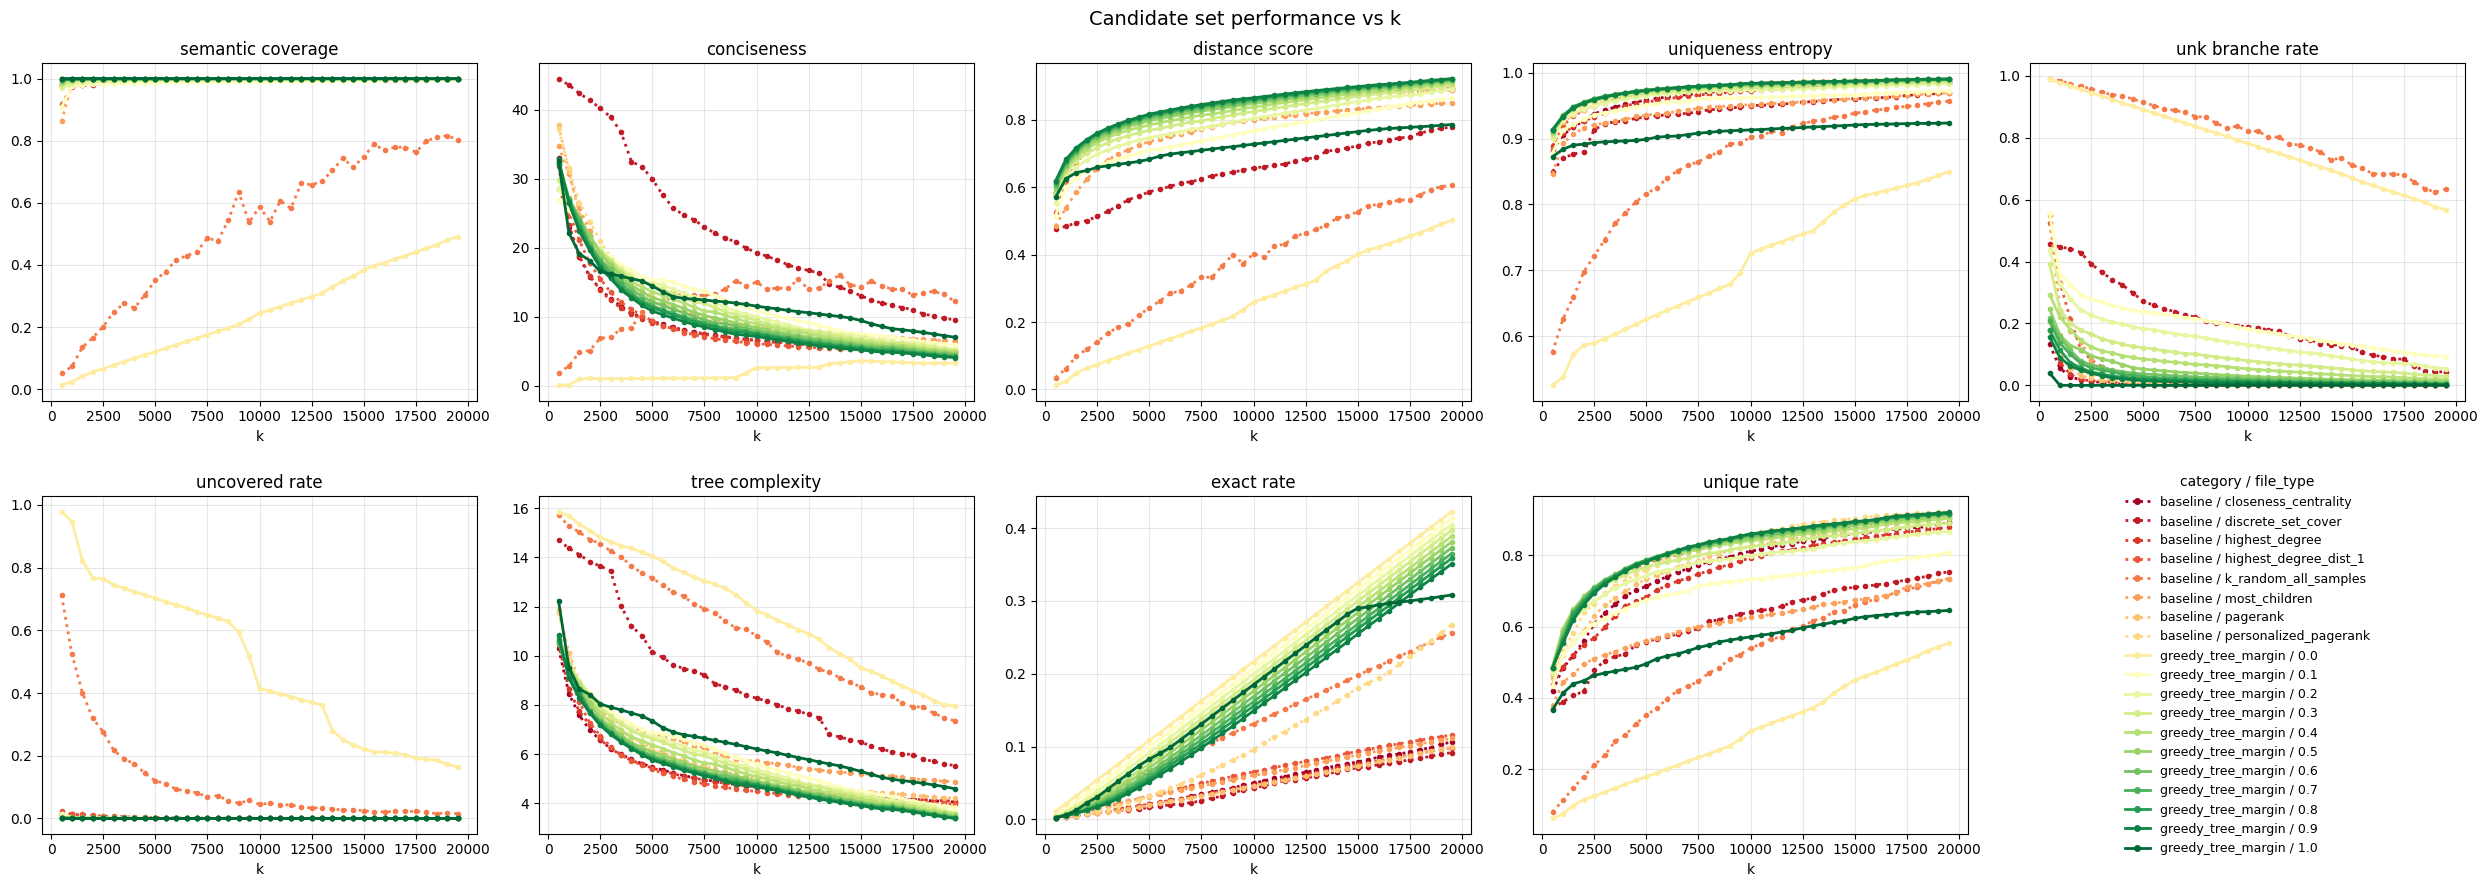

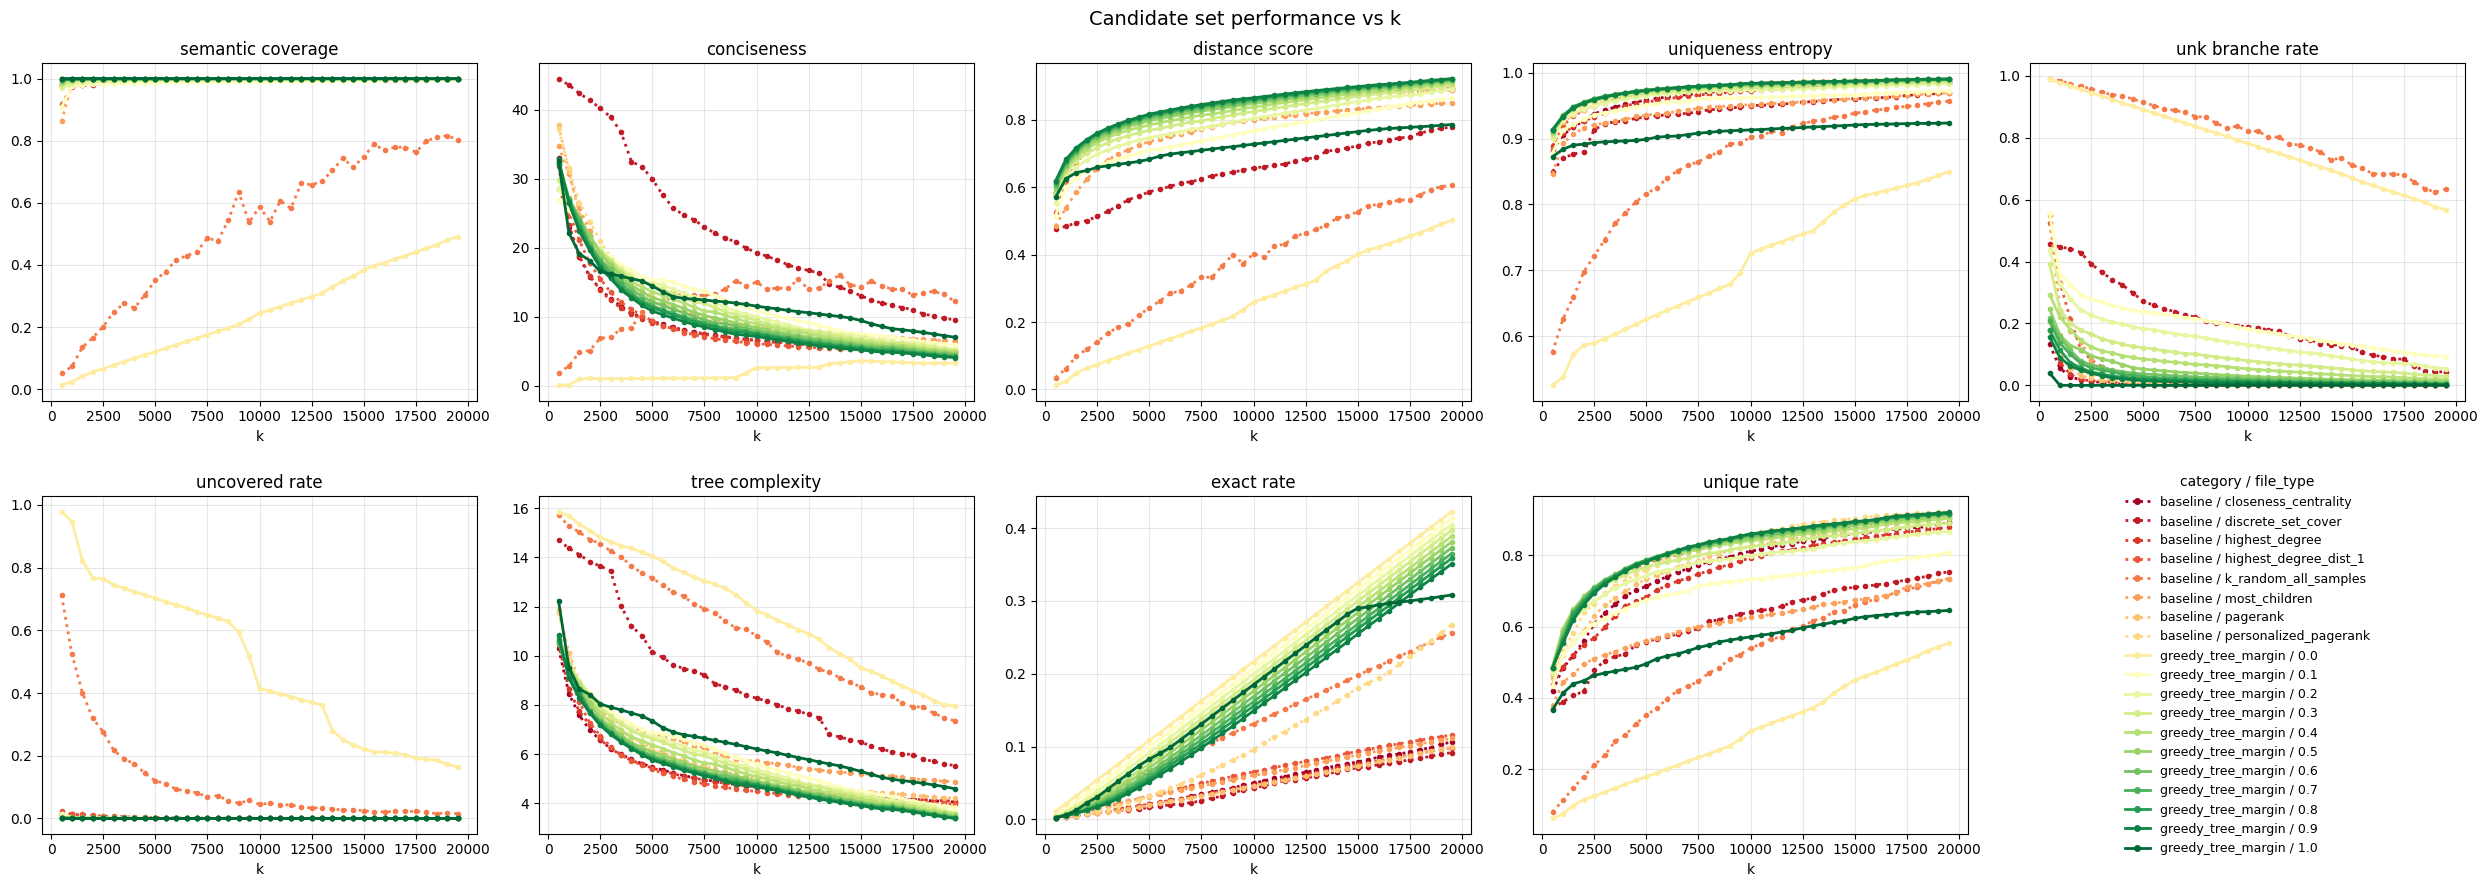

In [29]:
import matplotlib.pyplot as plt

def plot_candidate_performance(n_row, n_col,perf_df_all, metric_cols):
    """
    2x5 grid of metric-vs-k curves, one line per (category, file_type) series -- last slot
    holds the shared legend. Hue-varied ordinal ramp (red -> yellow -> green) keyed on sorted
    series order; baseline = dotted, greedy_tree_margin = solid, a second encoding on top of
    color so the two arms are distinguishable even without reading the legend.
    """
    series_keys = perf_df_all.select(["category", "file_type"]).unique().sort(["category", "file_type"]).rows()

    cmap = plt.get_cmap("RdYlGn")
    colors = {key: cmap(i / max(len(series_keys) - 1, 1)) for i, key in enumerate(series_keys)}
    linestyles = {key: (":" if key[0] == "baseline" else "-") for key in series_keys}

    fig, axes = plt.subplots(n_row, n_col, figsize=(25, 9))
    axes = axes.flatten()

    for ax, metric in zip(axes, metric_cols):
        for category, file_type in series_keys:
            sub = perf_df_all.filter((pl.col("category") == category) & (pl.col("file_type") == file_type))
            ax.plot(sub["k"], sub[metric], color=colors[(category, file_type)], linestyle=linestyles[(category, file_type)],
                     linewidth=2, marker="o", markersize=3)
        ax.set_title(metric.replace("_", " "))
        ax.set_xlabel("k")
        ax.grid(alpha=0.3)

    axes[-1].axis("off")  # 10th slot unused by metrics -- holds the shared legend instead
    handles = [
        plt.Line2D([0], [0], color=colors[key], linestyle=linestyles[key], lw=2, marker="o", markersize=4,
                   label=f"{key[0]} / {key[1]}")
        for key in series_keys
    ]
    axes[-1].legend(handles=handles, loc="center", fontsize=9, title="category / file_type", frameon=False)

    fig.suptitle("Candidate set performance vs k", fontsize=14)
    fig.tight_layout()
    return fig


plot_candidate_performance(2,5,perf_df_all, metric_cols)

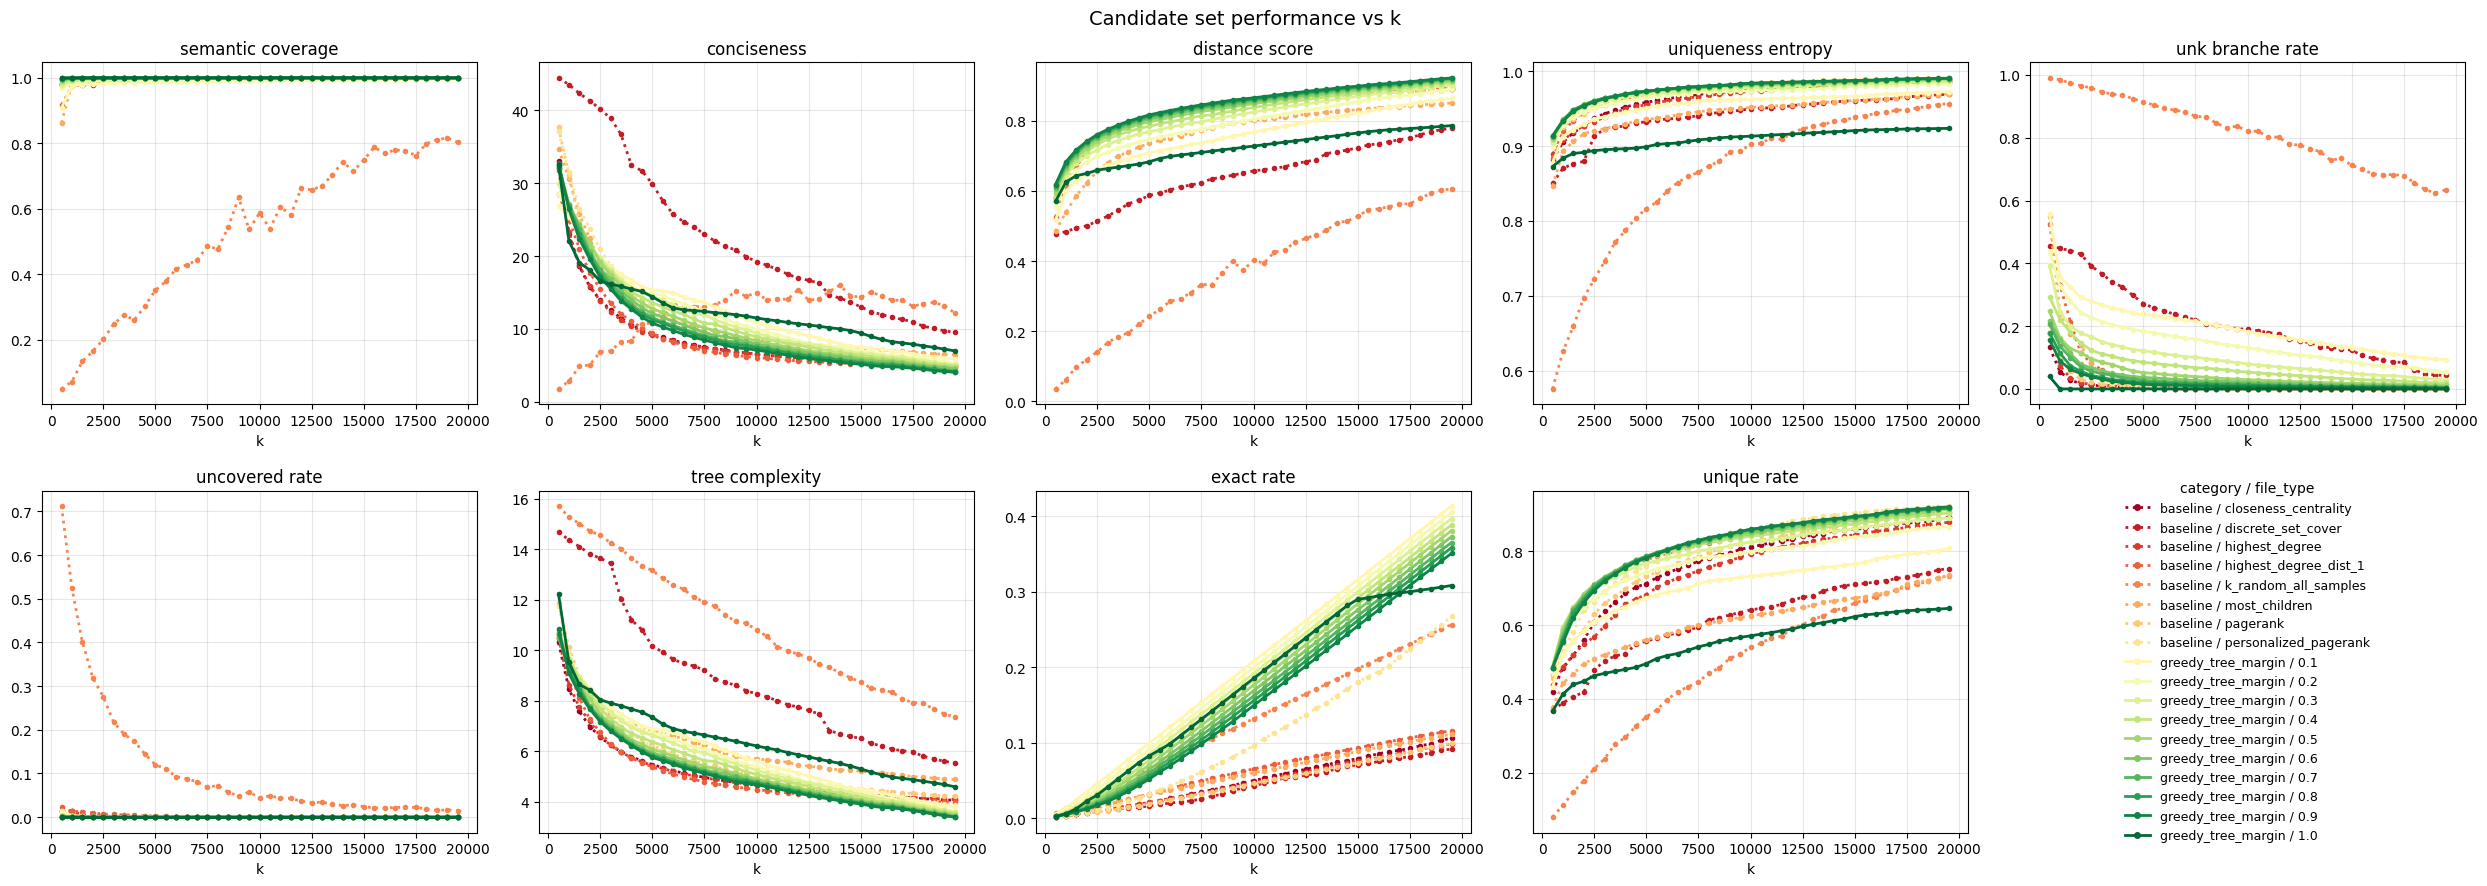

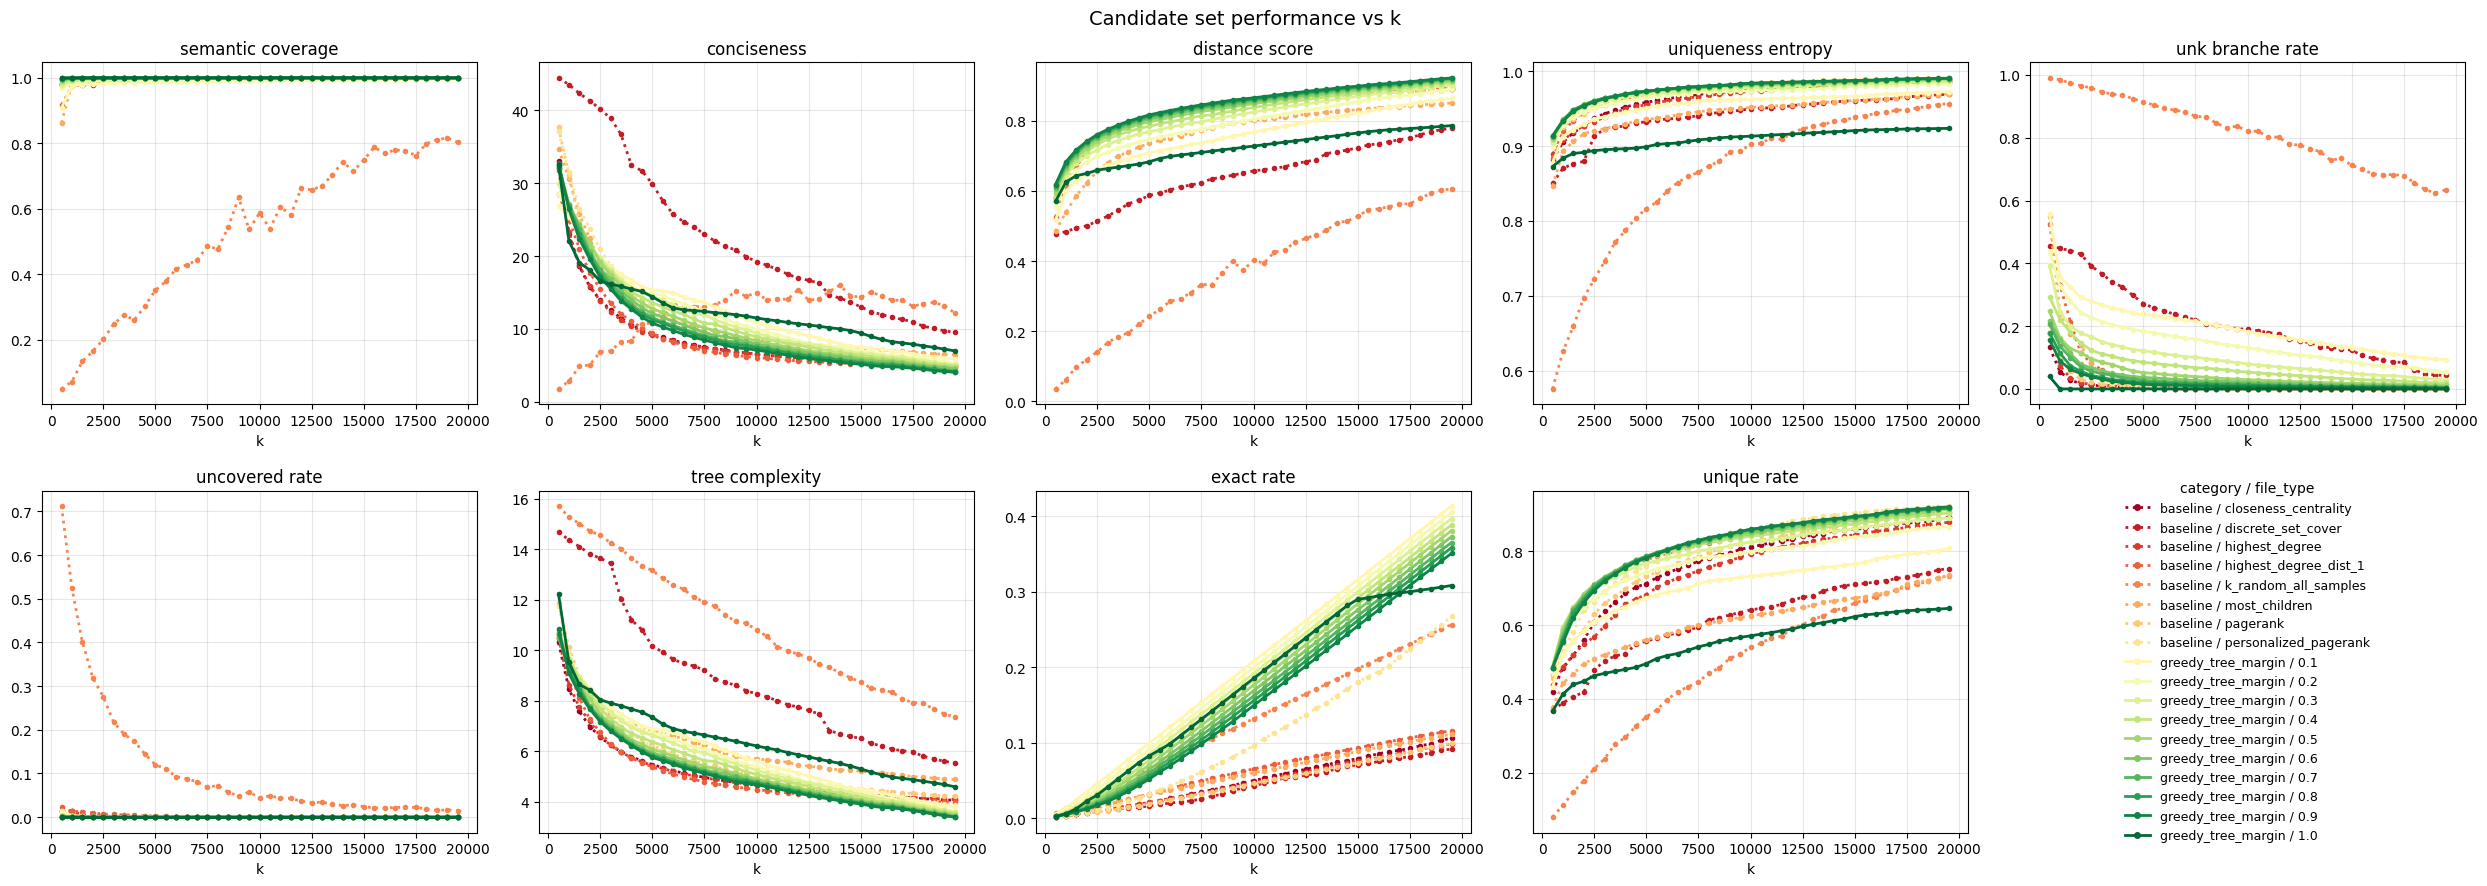

In [5]:
plot_candidate_performance(perf_df_all.filter(pl.col("file_type") != "0.0"), metric_cols)

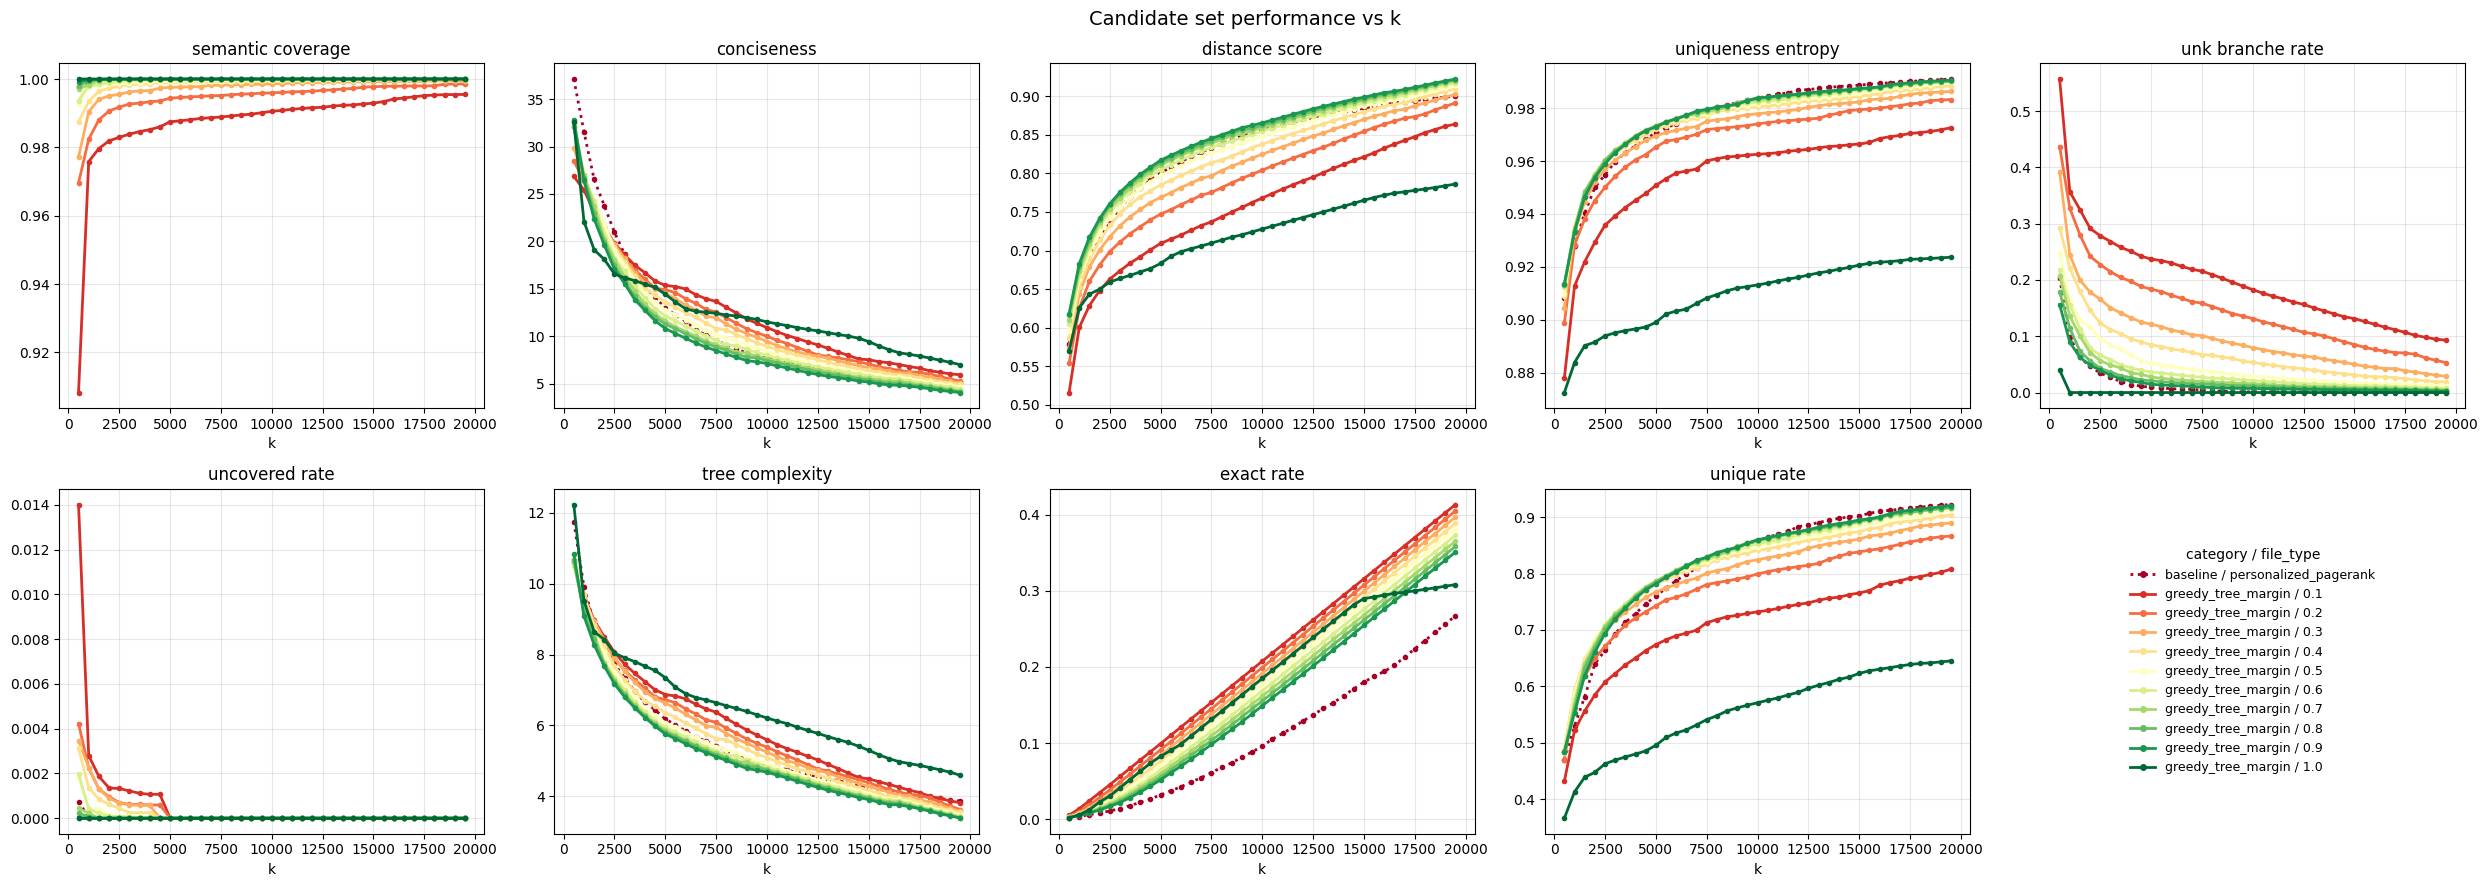

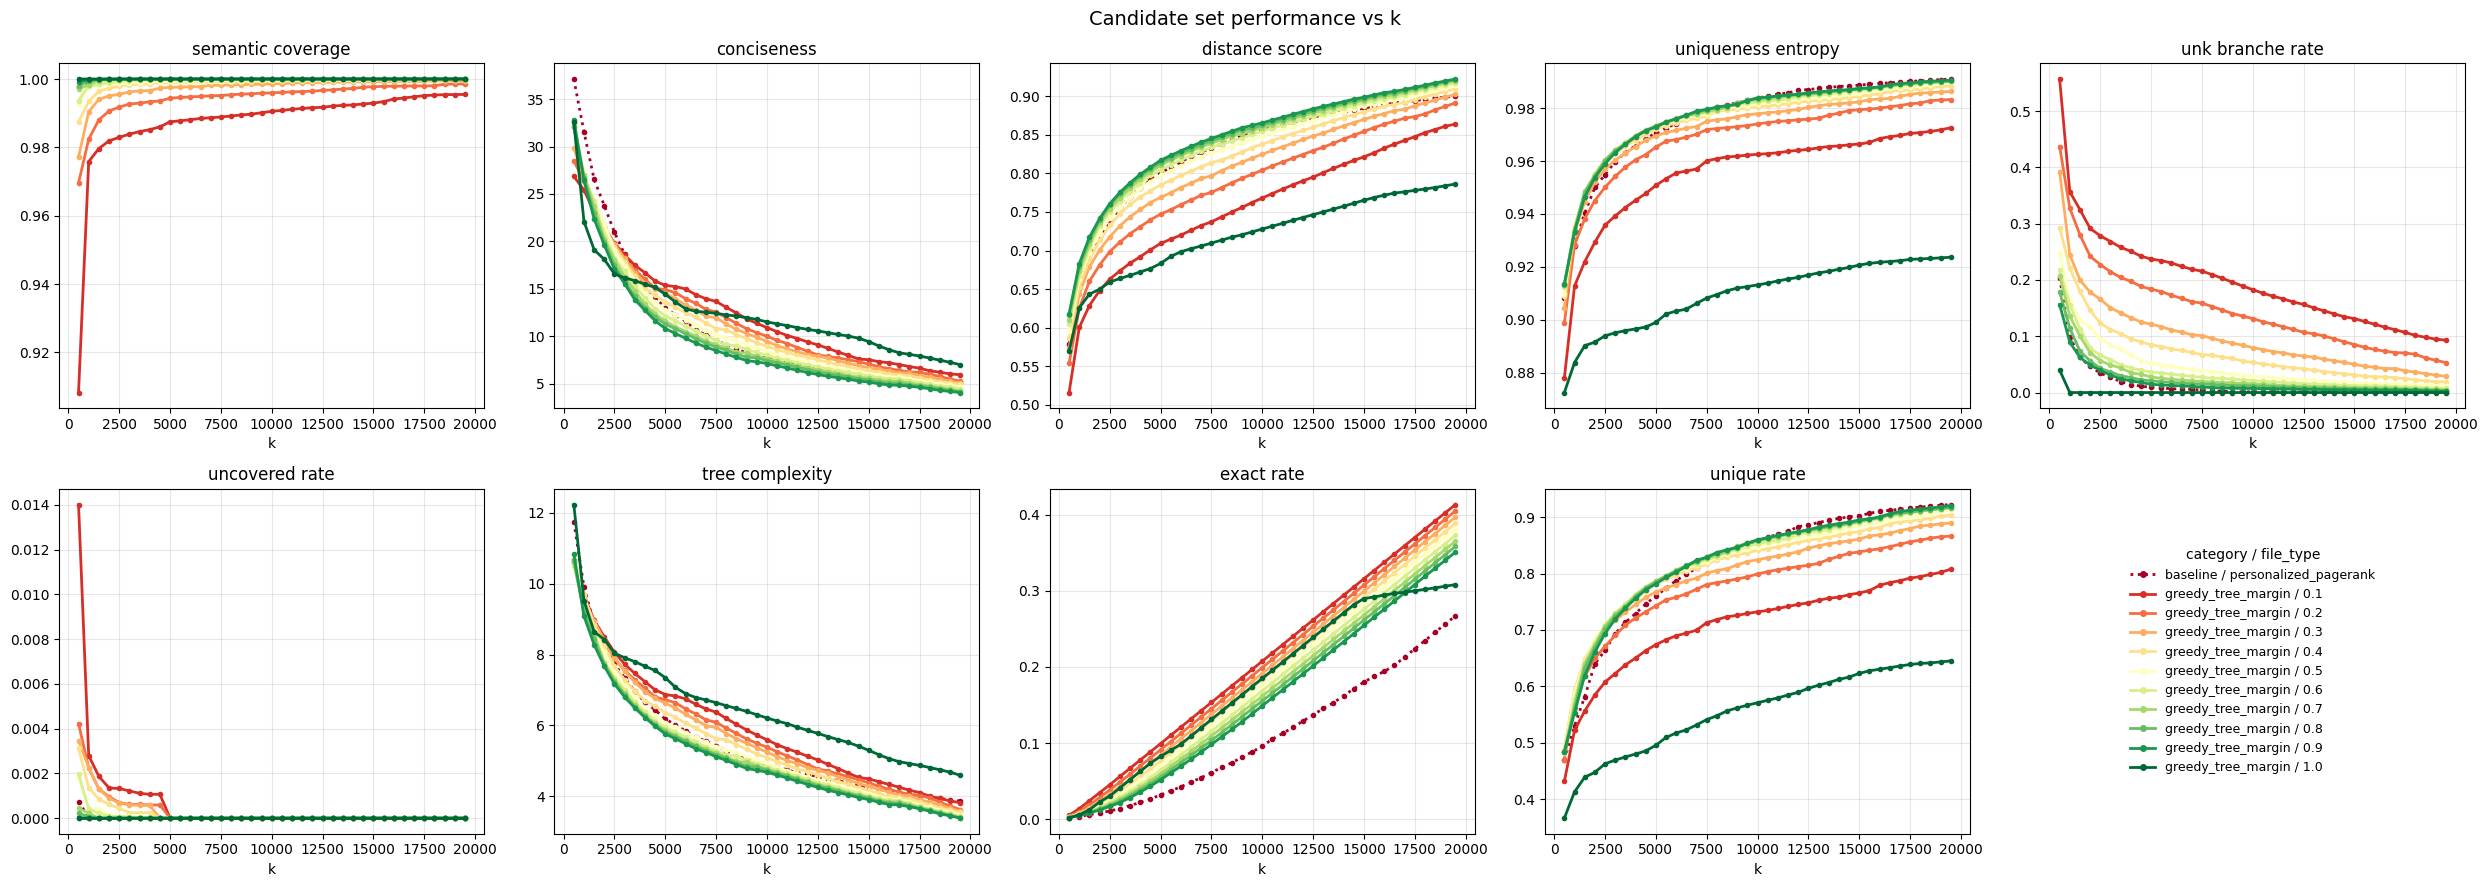

In [6]:
plot_candidate_performance(perf_df_all.filter(((pl.col("category") == "greedy_tree_margin") | (pl.col("file_type") == "personalized_pagerank")) & (pl.col("file_type") != "0.0")), metric_cols)


In [ ]:
plot_candidate_performance(perf_df_all.filter(((pl.col("category") == "greedy_tree_margin") | (pl.col("file_type") == "personalized_pagerank")) & (pl.col("file_type") != "0.0")), metric_cols)


In [8]:
pl.read_parquet(config.Results().perf_k_rdn_path)["iter"].max()

19

In [21]:
metric_cols

['semantic_coverage',
 'conciseness',
 'distance_score',
 'uniqueness_entropy',
 'unk_branche_rate',
 'uncovered_rate',
 'tree_complexity',
 'exact_rate',
 'unique_rate']

# article plots

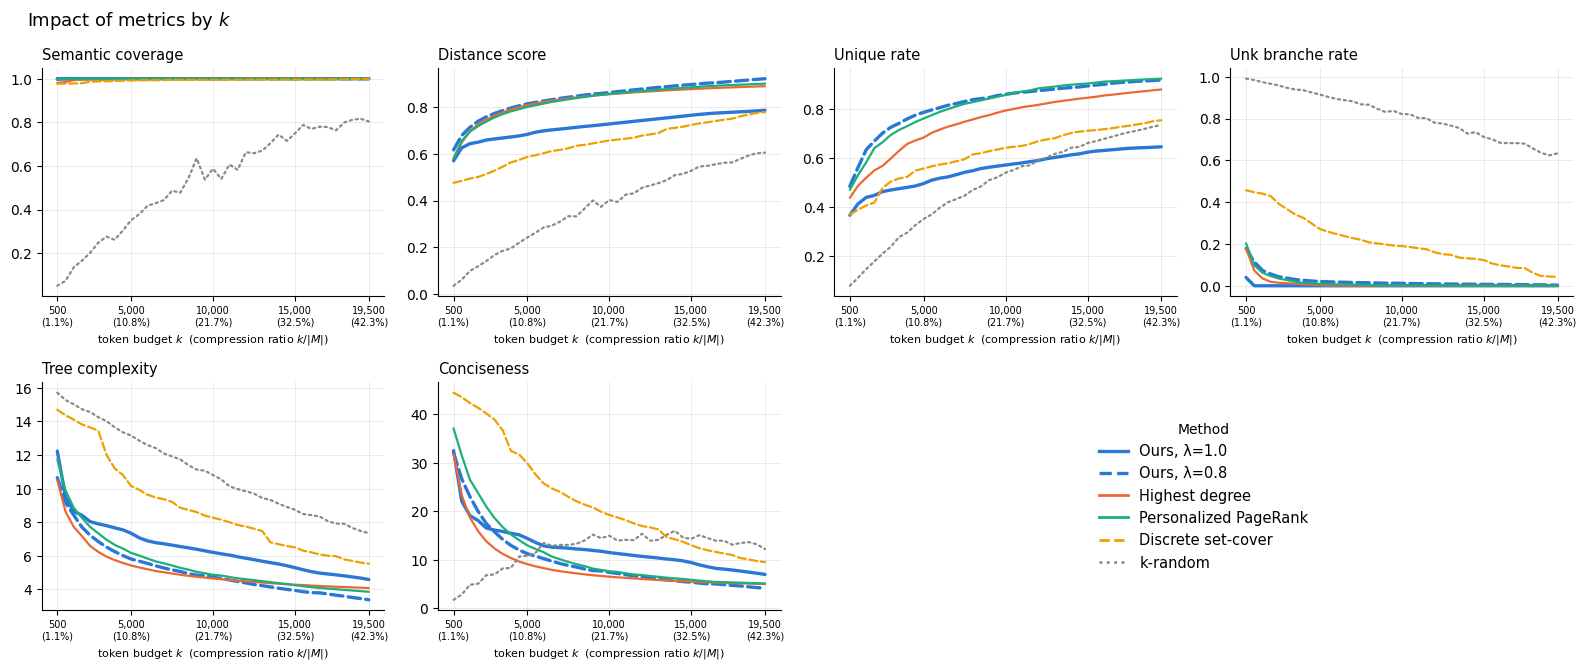

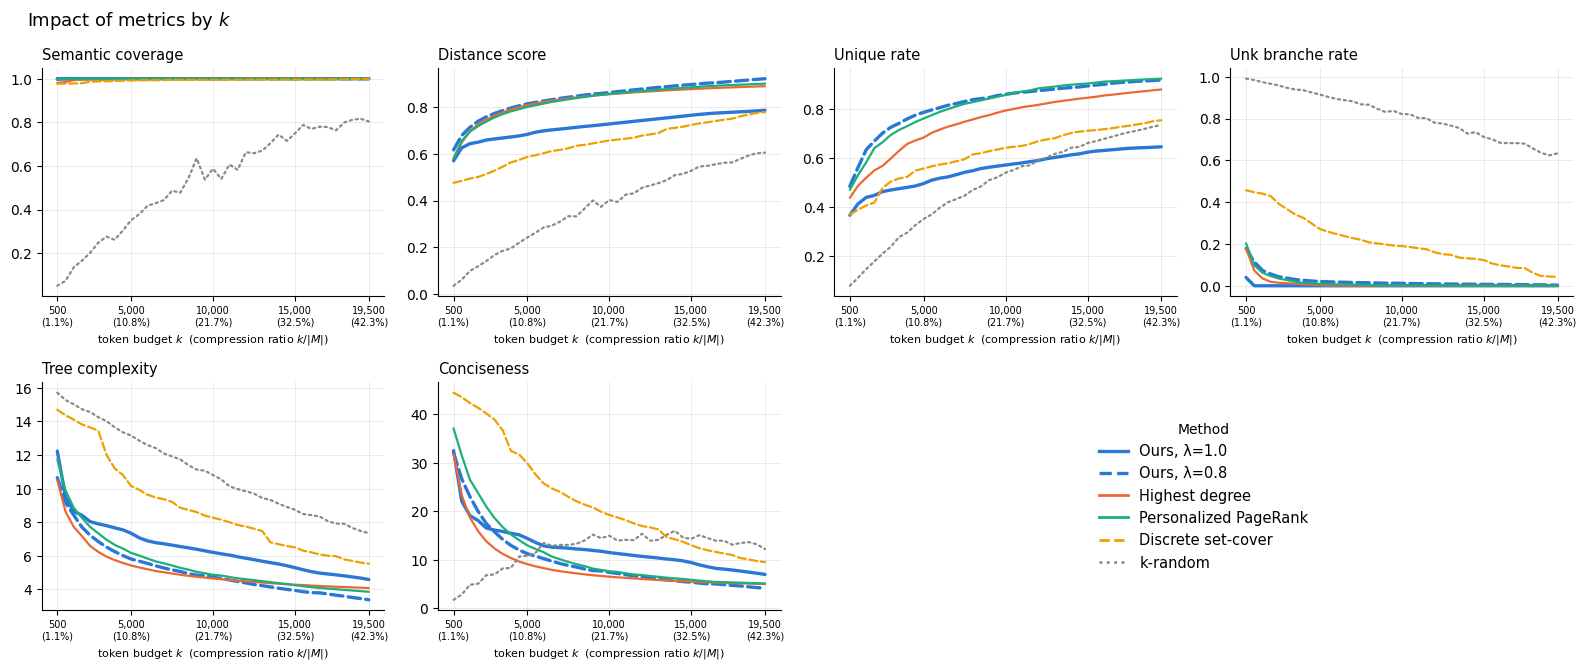

In [39]:
import polars as pl
import matplotlib.pyplot as plt

# Fixed, colorblind-validated categorical palette (not a sampled diverging colormap --
# RdYlGn puts pale yellow near the middle of the ramp, which is why personalized_pagerank
# was nearly invisible: a diverging colormap is the wrong tool for categorical identity).
_PALETTE = {
    "ours_1.0": "#2a78d6",
    "ours_0.8": "#2a78d6",
    "highest_degree": "#eb6834",
    "personalized_pagerank": "#1baf7a",
    "discrete_set_cover": "#eda100",
    "k_random": "#8a8a86",
}
_LINESTYLE = {
    "ours_1.0": "-",
    "ours_0.8": "--",
    "highest_degree": "-",
    "personalized_pagerank": "-",
    "discrete_set_cover": "--",
    "k_random": ":",
}
_LINEWIDTH = {"ours_1.0": 2.4, "ours_0.8": 2.4}  # everything else defaults to 1.6
_DISPLAY_NAME = {
    "ours_1.0": "Ours, λ=1.0",
    "ours_0.8": "Ours, λ=0.8",
    "highest_degree": "Highest degree",
    "personalized_pagerank": "Personalized PageRank",
    "discrete_set_cover": "Discrete set-cover",
    "k_random": "k-random",
}
# explicit (category, file_type) -> series key, so the plot shows exactly the six-way
# comparison the paper makes -- not every baseline in perf_df_all (closeness_centrality,
# pagerank, most_children, highest_degree_dist_1 stay out, and k_random's 20 iters collapse
# into one series instead of 20 overlapping raw lines)
_SERIES_MAP = {
    ("greedy_tree_margin", "1.0"): "ours_1.0",
    ("greedy_tree_margin", "0.8"): "ours_0.8",
    ("baseline", "highest_degree"): "highest_degree",
    ("baseline", "personalized_pagerank"): "personalized_pagerank",
    ("baseline", "discrete_set_cover"): "discrete_set_cover",
    ("baseline", "k_random_all_samples"): "k_random",
}


def plot_candidate_performance(perf_df_all, metric_cols, n_mapped_concepts, series_map=_SERIES_MAP,
                                save_path=None, dpi=300):
    """
    2x4 small-multiples grid of metric-vs-k curves, one line per series in `series_map`,
    aggregated over `iter` where present (k-random) and sorted by k. Slots after the
    metric panels (6 and 7, for the current 6-metric call) merge into one wide legend
    box rather than a single cramped cell. Pass `save_path` to also write the figure to
    disk at `dpi` (default 300, print/publication quality).
    """
    n_row, n_col = 2, 4
    assert len(metric_cols) <= n_row * n_col - 2, "2x4 grid only fits 6 metric panels + a merged legend box"

    fig = plt.figure(figsize=(4.0 * n_col, 3.4 * n_row))
    gs = fig.add_gridspec(n_row, n_col)
    axes = [fig.add_subplot(gs[i // n_col, i % n_col]) for i in range(len(metric_cols))]

    # remaining slots (6 and 7, for the current 6-metric call) merge into one wide
    # legend box -- gs[r0:, c0:] spans everything from the first unused slot to the
    # end of the grid.
    r0, c0 = divmod(len(metric_cols), n_col)
    legend_ax = fig.add_subplot(gs[r0:, c0:])
    legend_ax.axis("off")

    # one row per series: aggregate over iter (mean) if present, sort by k
    group_cols = ["category", "file_type", "k"]
    agg_df = (
        perf_df_all.group_by(group_cols)
        .agg([pl.col(m).mean() for m in metric_cols])
        .sort("k")
    )

    # max k actually plotted, computed once over every series in series_map --
    # not left over from whichever series happens to be last in the dict, which
    # would silently truncate tick labels if that series had a shorter k range.
    plotted_mask = pl.struct(["category", "file_type"]).is_in(
        [{"category": c, "file_type": f} for c, f in series_map]
    )
    k_max = agg_df.filter(plotted_mask)["k"].max()

    for ax, metric in zip(axes, metric_cols):
        for (category, file_type), key in series_map.items():
            sub = agg_df.filter((pl.col("category") == category) & (pl.col("file_type") == file_type))
            if sub.is_empty():
                continue
            ax.plot(
                sub["k"], sub[metric],
                color=_PALETTE[key],
                linestyle=_LINESTYLE[key],
                linewidth=_LINEWIDTH.get(key, 1.6),
                solid_capstyle="round", dash_capstyle="round",
            )
        ax.set_title(metric.replace("_", " ").capitalize(), fontsize=10.5, loc="left")
        ax.spines[["top", "right"]].set_visible(False)
        ax.grid(alpha=0.25, linewidth=0.7)
        xticks = [500, 5000, 10000, 15000, 19500]
        xticks = [t for t in xticks if t <= k_max]
        ax.set_xticks(xticks)
        ax.set_xticklabels([f"{t:,}\n({t / n_mapped_concepts * 100:.1f}%)" for t in xticks], fontsize=7)
        ax.set_xlabel("token budget $k$  (compression ratio $k/|M|$)", fontsize=8)

    handles = [
        plt.Line2D([0], [0], color=_PALETTE[key], linestyle=_LINESTYLE[key],
                   linewidth=max(_LINEWIDTH.get(key, 1.6), 2.0), label=_DISPLAY_NAME[key])
        for key in series_map.values()
    ]
    legend_ax.legend(handles=handles, loc="center", fontsize=10.5, title="Method", frameon=False)

    fig.suptitle("Impact of metrics by $k$", fontsize=13, x=0.02, ha="left")
    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")

    return fig


plot_candidate_performance(
    perf_df_all,
    metric_cols=["semantic_coverage", "distance_score", "unique_rate", "unk_branche_rate", "tree_complexity", "conciseness"],
    n_mapped_concepts=46_150,
    save_path="figures/impact_of_metrics_by_k.png",
)

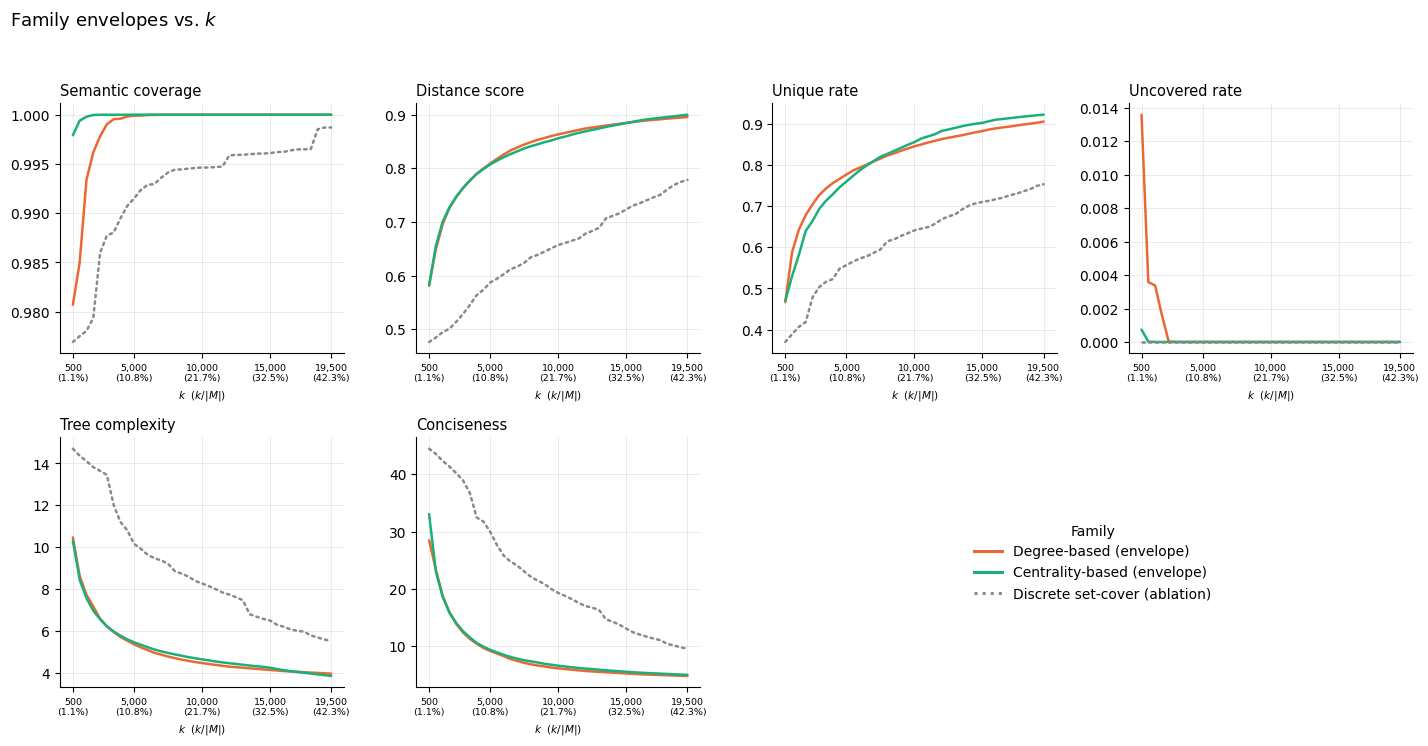

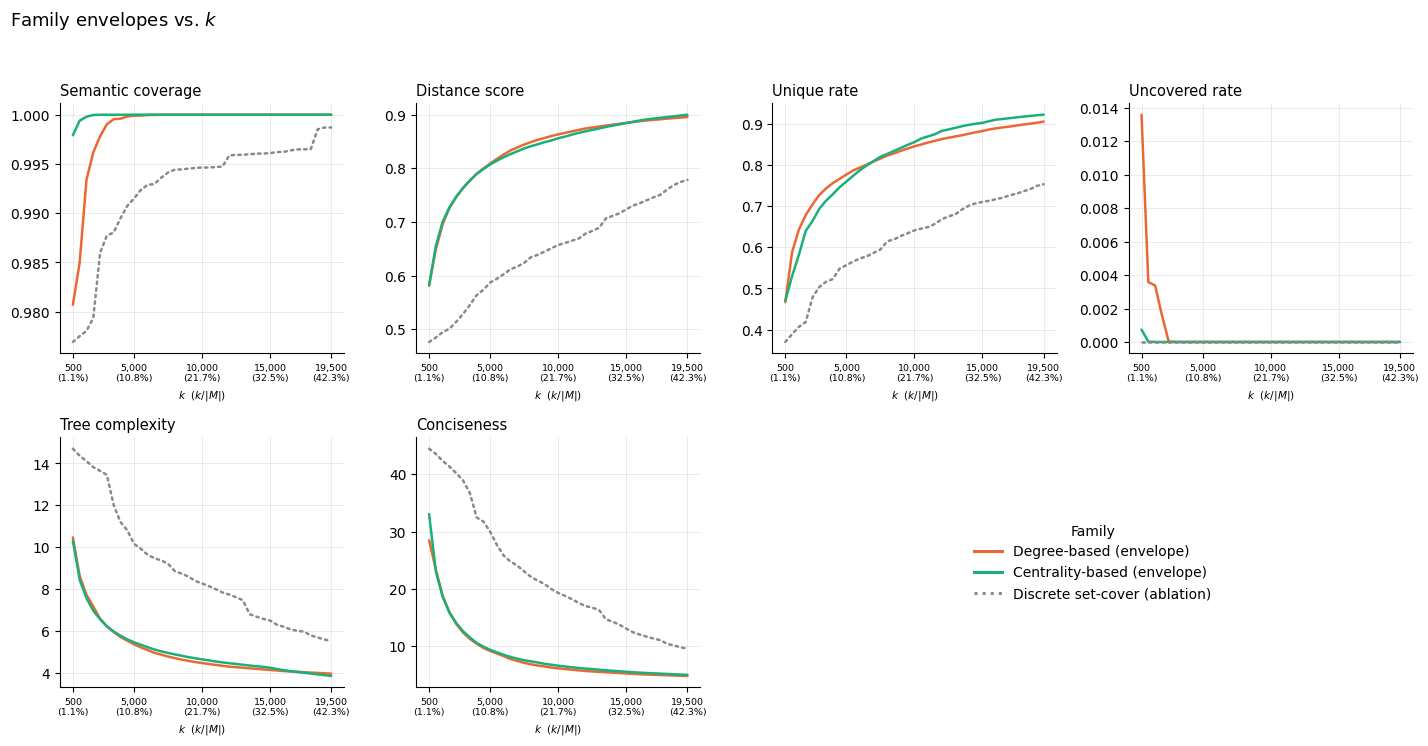

In [54]:
import polars as pl
import matplotlib.pyplot as plt

# family membership -- edit these lists if you add/drop baseline variants
_DEGREE_MEMBERS = ["highest_degree", "most_children", "highest_degree_dist_1"]
_CENTRALITY_MEMBERS = ["personalized_pagerank", "pagerank", "closeness_centrality"]
_DISCRETE_SET_COVER = "discrete_set_cover"

# direction of "best" per metric -- most metrics are higher-is-better (max), but these
# three are lower-is-better, so the envelope should take their min instead
_LOWER_IS_BETTER = {"uncovered_rate", "conciseness", "tree_complexity"}

_PALETTE = {
    "ours": "#2a78d6",
    "degree": "#eb6834",
    "centrality": "#1baf7a",
    "discrete_set_cover": "#8a8a86",
}
_LINESTYLE = {"degree": "-", "centrality": "-", "discrete_set_cover": ":"}
_LINEWIDTH = {"degree": 1.8, "centrality": 1.8, "discrete_set_cover": 1.8}
_DISPLAY_NAME = {
    "degree": "Degree-based (envelope)",
    "centrality": "Centrality-based (envelope)",
    "discrete_set_cover": "Discrete set-cover (ablation)",
}


def _family_envelope(perf_df_all, category, file_types, metric_cols):
    """
    Best value at each k across the given file_types within one category -- max for
    higher-is-better metrics, min for lower-is-better ones (see _LOWER_IS_BETTER).
    """
    aggs = [(pl.col(m).min() if m in _LOWER_IS_BETTER else pl.col(m).max()) for m in metric_cols]
    return (
        perf_df_all.filter((pl.col("category") == category) & (pl.col("file_type").is_in(file_types)))
        .group_by("k")
        .agg(aggs)
        .sort("k")
    )


def plot_family_envelopes(perf_df_all, metric_cols, n_mapped_concepts, save_path=None, dpi=300):
    """
    Upper-envelope-per-family plot: best member of the degree-based family, best member
    of the centrality-based family, our method's envelope over lambda, and the discrete
    set-cover ablation (a single method, no envelope) -- one line each, vs k. Laid out
    as a 2x4 grid; slots after the metric panels (6 and 7, for the current 6-metric
    call) merge into one wide legend box.

    Pass `save_path` to also write the figure to disk at `dpi` (default 300).
    """

    deg_env = _family_envelope(perf_df_all, "baseline", _DEGREE_MEMBERS, metric_cols)
    cen_env = _family_envelope(perf_df_all, "baseline", _CENTRALITY_MEMBERS, metric_cols)
    dsc = (
        perf_df_all.filter((pl.col("category") == "baseline") & (pl.col("file_type") == _DISCRETE_SET_COVER))
        .sort("k")
    )

    series = {
        "degree": deg_env,
        "centrality": cen_env,
        "discrete_set_cover": dsc,
    }

    n_row, n_col = 2, 4
    assert len(metric_cols) <= n_row * n_col - 2, "2x4 grid only fits 6 metric panels + a merged legend box"

    fig = plt.figure(figsize=(3.6 * n_col, 3.6 * n_row))
    gs = fig.add_gridspec(n_row, n_col)
    axes = [fig.add_subplot(gs[i // n_col, i % n_col]) for i in range(len(metric_cols))]

    # remaining slots (6 and 7, for the current 6-metric call) merge into one wide
    # legend box -- gs[r0:, c0:] spans everything from the first unused slot to the
    # end of the grid.
    r0, c0 = divmod(len(metric_cols), n_col)
    legend_ax = fig.add_subplot(gs[r0:, c0:])
    legend_ax.axis("off")

    xticks = [500, 5000, 10000, 15000, 19500]
    # max k across every series, computed once -- not read off whichever series
    # happens to be last inside the per-metric loop below.
    k_max = max(df["k"].max() for df in series.values())
    ticks = [t for t in xticks if t <= k_max]

    for ax, metric in zip(axes, metric_cols):
        for key, df in series.items():
            ax.plot(
                df["k"], df[metric],
                color=_PALETTE[key], linestyle=_LINESTYLE[key], linewidth=_LINEWIDTH[key],
                solid_capstyle="round", dash_capstyle="round",
            )
        ax.set_title(metric.replace("_", " ").capitalize(), fontsize=10.5, loc="left")
        ax.spines[["top", "right"]].set_visible(False)
        ax.grid(alpha=0.25, linewidth=0.7)
        ax.set_xticks(ticks)
        ax.set_xticklabels([f"{t:,}\n({t / n_mapped_concepts * 100:.1f}%)" for t in ticks], fontsize=6.8)
        ax.set_xlabel("$k$  ($k/|M|$)", fontsize=7.6)

    handles = [
        plt.Line2D([0], [0], color=_PALETTE[k], linestyle=_LINESTYLE[k],
                   linewidth=max(_LINEWIDTH[k], 2.2), label=_DISPLAY_NAME[k])
        for k in series
    ]
    legend_ax.legend(handles=handles, loc="center", fontsize=10, title="Family", frameon=False)

    fig.suptitle("Family envelopes vs. $k$", fontsize=13, x=0.01, ha="left", y=1.03)
    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")

    return fig


plot_family_envelopes(
    perf_df_all.filter(pl.col("category").str.contains("baseline")),
    metric_cols_new,
    n_mapped_concepts=46_150,
    save_path="figures/family_envelopes.png",
)

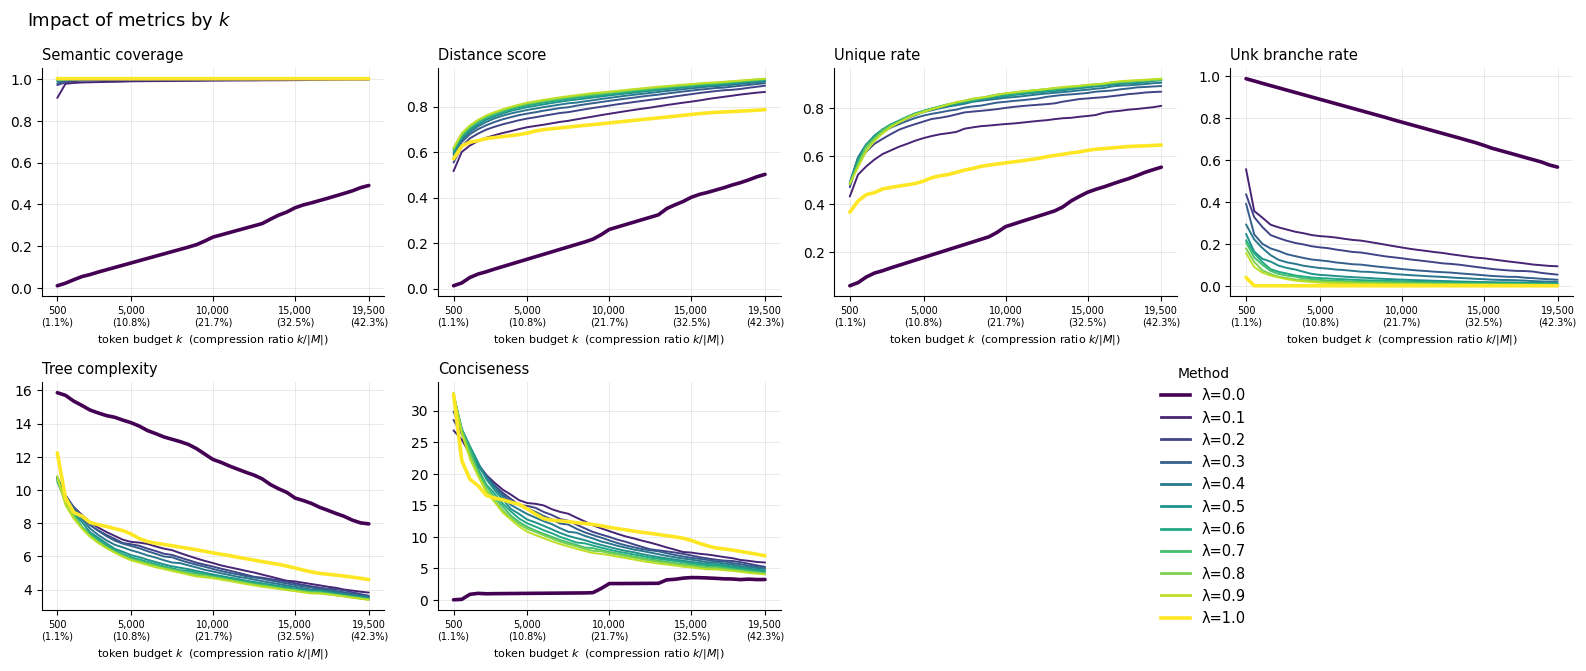

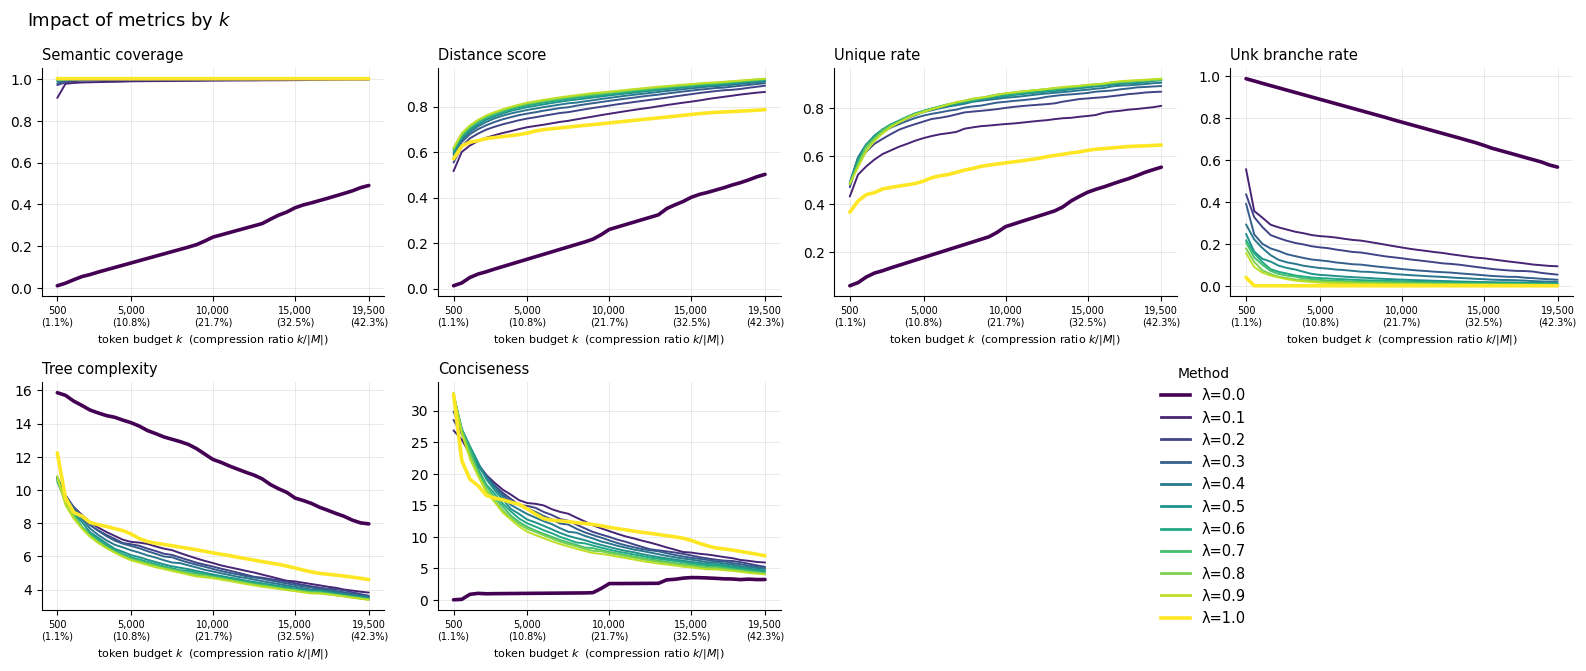

In [59]:
_LAMBDAS = ["0.0", "0.1", "0.2", "0.3", "0.4", "0.5", "0.6", "0.7", "0.8", "0.9", "1.0"]

_lambda_cmap = plt.get_cmap("viridis")
_PALETTE = {lam: _lambda_cmap(i / (len(_LAMBDAS) - 1)) for i, lam in enumerate(_LAMBDAS)}
_LINESTYLE = {lam: "-" for lam in _LAMBDAS}
_LINEWIDTH = {lam: (2.6 if lam in ("0.0", "1.0") else 1.4) for lam in _LAMBDAS}  # bookend the sweep
_DISPLAY_NAME = {lam: f"λ={lam}" for lam in _LAMBDAS}

_SERIES_MAP = {("greedy_tree_margin", lam): lam for lam in _LAMBDAS}


plot_candidate_performance(
    perf_df_all.filter(pl.col("category").str.contains("greedy")),
    metric_cols=["semantic_coverage", "distance_score", "unique_rate", "unk_branche_rate", "tree_complexity", "conciseness"],
    n_mapped_concepts=46_150,
    series_map=_SERIES_MAP,
    save_path="figures/lambda_effect.png",
)


In [57]:
perf_df_all.filter(pl.col("category").str.contains("greedy")),


(shape: (429, 12)
 ┌────────────┬───────────┬───────┬────────────┬───┬────────────┬───────────┬───────────┬───────────┐
 │ category   ┆ file_type ┆ k     ┆ concisenes ┆ … ┆ tree_compl ┆ exact_rat ┆ unique_ra ┆ semantic_ │
 │ ---        ┆ ---       ┆ ---   ┆ s          ┆   ┆ exity      ┆ e         ┆ te        ┆ coverage  │
 │ str        ┆ str       ┆ i64   ┆ ---        ┆   ┆ ---        ┆ ---       ┆ ---       ┆ ---       │
 │            ┆           ┆       ┆ f64        ┆   ┆ f64        ┆ f64       ┆ f64       ┆ f64       │
 ╞════════════╪═══════════╪═══════╪════════════╪═══╪════════════╪═══════════╪═══════════╪═══════════╡
 │ greedy_tre ┆ 0.0       ┆ 500   ┆ 0.024464   ┆ … ┆ 15.85571   ┆ 0.010834  ┆ 0.061495  ┆ 0.012243  │
 │ e_margin   ┆           ┆       ┆            ┆   ┆            ┆           ┆           ┆           │
 │ greedy_tre ┆ 0.0       ┆ 1000  ┆ 0.090423   ┆ … ┆ 15.694518  ┆ 0.021668  ┆ 0.07441   ┆ 0.024556  │
 │ e_margin   ┆           ┆       ┆            ┆   ┆            